Connected to cgf (Python 3.12.11)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from rpy2.robjects import pandas2ri, r, default_converter
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from typing import Any
import matplotlib.pyplot as plt

from rra_climate_health.model_specification import ModelSpecification
from rra_climate_health.data import DEFAULT_ROOT, ClimateMalnutritionData

In [ ]:
def get_scam_spline_effect(
    model, var_name, data_source, n_points=100, value_source=None
):
    scam_lib = importr("scam")
    grid_df = data_source.iloc[[0] * n_points].reset_index(drop=True).copy()
    vmin, vmax = data_source[var_name].min(), data_source[var_name].max()
    grid_np = np.linspace(vmin, vmax, n_points)
    grid_df[var_name] = grid_np
    with localconverter(default_converter + pandas2ri.converter):
        r_grid_df = pandas2ri.py2rpy(grid_df)
    pred = scam_lib.predict_scam(model, newdata=r_grid_df, type="terms", se_fit=True)

    fit_matrix = np.array(pred.rx2("fit"))
    se_matrix = np.array(pred.rx2("se.fit"))
    col_names = list(r.colnames(pred.rx2("fit")))

    target_col = [i for i, name in enumerate(col_names) if f"s({var_name})" in name][0]

    if value_source is not None:
        real_min, real_max = value_source[var_name].min(), value_source[var_name].max()
        real_value_grid_np = np.linspace(real_min, real_max, n_points)

    return pd.DataFrame(
        {
            "value": real_value_grid_np if value_source is not None else grid_np,
            "effect": fit_matrix[:, target_col],
            "se": se_matrix[:, target_col],
        }
    )


def extract_knots_from_model(model, predictor_name):
    # Extract knots from the fitted model object
    smooth_terms = model.rx2("smooth")
    for i in range(len(smooth_terms)):
        term = smooth_terms[i]
        if term.rx2("term")[0] == predictor_name:
            return term.rx2("knots")
    raise ValueError(f"Predictor {predictor_name} not found in model smooth terms")


def plot_scam_spline(
    effect_df, original_data, var_name, knots=None, title=None, filepath=None
):
    """
    Plots a SCAM spline effect with 95% CI and a rug plot.

    Parameters:
    - effect_df: DataFrame with ['value', 'effect', 'se']
    - original_data: The full DataFrame (used for the rug plot)
    - var_name: Name of the variable being plotted (e.g., 'temperature')
    - knots: List of knot values (optional)
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Plot the Partial Effect (Spline)
    ax.plot(
        effect_df["value"],
        effect_df["effect"],
        color="#2c3e50",
        lw=2.5,
        label="Partial Effect",
    )

    # 2. Add 95% Confidence Interval (1.96 * SE)
    lower_ci = effect_df["effect"] - (1.96 * effect_df["se"])
    upper_ci = effect_df["effect"] + (1.96 * effect_df["se"])

    ax.fill_between(
        effect_df["value"],
        lower_ci,
        upper_ci,
        color="#3498db",
        alpha=0.2,
        label="95% CI",
    )

    # 3. Add the Rug Plot (The 'Rug' represents actual data distribution)
    # We place it at the very bottom of the current Y-axis
    obs = original_data[var_name].dropna()
    y_min = ax.get_ylim()[0]
    ax.plot(
        obs,
        np.full_like(obs, y_min),
        "|",
        color="black",
        alpha=0.2,
        markersize=12,
        markeredgewidth=0.4,
    )

    # 4. Reference line at 0 (No effect)
    ax.axhline(0, color="red", linestyle="--", alpha=0.4, lw=1)

    # 5. Add vertical lines for knots if provided
    if knots is not None:
        for knot in knots:
            ax.axvline(
                knot,
                color="green",
                linestyle=":",
                alpha=0.7,
                lw=1.5,
                label="Knot" if knot == knots[0] else None,
            )

    # 5. Aesthetics
    ax.set_xlabel(f"{var_name}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Partial Effect (Log-Odds)", fontsize=12, fontweight="bold")

    full_title = title if title else f"SCAM Spline Effect: {var_name}"
    ax.set_title(full_title, fontsize=14, pad=15)

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(frameon=True, loc="best")

    plt.tight_layout()
    if filepath:
        plt.savefig(filepath, dpi=300)
    else:
        plt.show()

In [ ]:
def merge_gbd_data(  # noqa: PLR0915
    measure: str, fitted_data: pd.DataFrame, fitted_column="fits"
) -> plt.Figure:  # type: ignore[name-defined]
    from rra_climate_health.data_prep.location_mapping import FHS_HIERARCHY_PATH

    root = Path(DEFAULT_ROOT)
    fhs_loc_meta = (
        pd.read_parquet(FHS_HIERARCHY_PATH)
        .sort_values("sort_order")
        .reset_index(drop=True)
    )

    gbd = pd.read_parquet(
        root / "input" / "gbd_prevalence" / f"gbd_mean_{measure}_prevalence.parquet"
    ).reset_index()
    fitted_data = fitted_data.copy()
    # Align dtypes for merge
    for col in fitted_data.columns:
        if col in gbd.columns:
            fitted_data[col] = fitted_data[col].astype(gbd[col].dtype)

    gbd = gbd.merge(
        fhs_loc_meta[["ihme_loc_id", "location_id"]],
        on="location_id",
        how="left",
        validate="many_to_one",
    )
    # take out location_id from index, add ihme_loc_id
    if measure == "neonatal_mortality":
        gbd = gbd.reset_index().set_index(["ihme_loc_id", "year_id", "sex_id"])
    else:
        gbd = gbd.reset_index().set_index(
            ["ihme_loc_id", "year_id", "age_group_id", "sex_id"]
        )
    gbd = gbd.drop(
        columns=[
            x for x in gbd.columns if x not in ["gbd_mean_prevalence", "location_id"]
        ],
        errors="ignore",
    )
    gbd = gbd.rename(columns={"gbd_mean_prevalence": "gbd"})

    if measure == "neonatal_mortality":
        prediction = (
            fitted_data.rename(columns={fitted_column: "pred", "birth_year": "year_id"})
            .groupby(["ihme_loc_id", "year_id", "sex_id"])
            .agg({measure: "mean", "pred": "mean"})
        )
    else:
        prediction = (
            fitted_data.rename(columns={fitted_column: "pred", "year_start": "year_id"})
            .groupby(["ihme_loc_id", "year_id", "age_group_id", "sex_id"])
            .agg({measure: "mean", "pred": "mean"})
        )
    plot_data = (
        prediction.join(gbd)
        # .dropna()
    )
    return plot_data


def plot_gbd_comparison(
    plot_data: pd.DataFrame, measure: str, title: str, filepath=None
):
    rmse = np.sqrt(np.mean((plot_data["gbd"] - plot_data["pred"]) ** 2))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(plot_data["gbd"], plot_data["pred"], alpha=0.5)
    ax.plot(
        [plot_data["gbd"].min(), plot_data["gbd"].max()],
        [plot_data["gbd"].min(), plot_data["gbd"].max()],
        "r--",
    )
    ax.set_xlabel("GBD Prevalence", fontsize=12, fontweight="bold")
    ax.set_ylabel("Model Predicted Prevalence", fontsize=12, fontweight="bold")
    ax.set_title(title + f"\nRMSE: {rmse:.4f}", fontsize=14, pad=15)
    # Include RMSE as subtitle
    ax.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    if filepath:
        plt.savefig(filepath, dpi=300)
    else:
        plt.show()


def plot_model_heatmaps(df: str, measure: str, filepath: str = None) -> plt.Figure:  # type: ignore[name-defined]

    import seaborn as sns
    import matplotlib.colors as mcolors
    import matplotlib.pyplot as plt

    threshold_varname = next(
        (x for x in df.columns if (x.startswith("days_over")) | x.startswith("q")), None
    )
    if not threshold_varname:
        error_message = "No threshold variable found"
        raise ValueError(error_message)

    number_size = 16
    tick_size = 16
    axislabel_size = 18
    paneltitle_size = 18

    df[threshold_varname], o30_bins = pd.qcut(
        df.loc[df[threshold_varname] > 0, threshold_varname], 8, retbins=True
    )
    o30_bins = [0] + o30_bins
    if measure == "neonatal_mortality":
        df["ldi"], ldi_bins = pd.qcut(df["consumption_pd"], 10, retbins=True)
    else:
        df["ldi"], ldi_bins = pd.qcut(df.ldi_pc_pd, 10, retbins=True)

    x_ticks = range(len(o30_bins))
    x_labs = [f"{x:.1f}" for x in o30_bins]

    y_ticks = range(len(ldi_bins))
    y_labs = [f"{x:.1f}" for x in ldi_bins]

    vmin = 0
    vmax_dict = {
        "stunting": 0.5,
        "wasting": 0.25,
        "underweight": 0.40,
        "anemia": 0.7,
        "lbw": 0.25,
        "neonatal_mortality": 45,
    }
    vmax = vmax_dict[measure]
    colorbin_interval = (vmax - vmin) / 10
    boundaries = np.arange(vmin, vmax + colorbin_interval, colorbin_interval)
    cmap = plt.get_cmap("RdYlBu_r", len(boundaries) - 1)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N, clip=True)

    if measure == "neonatal_mortality":
        df[measure] = df[measure] * 1000  # convert to per 1000 live births
        df["fits"] = df["fits"] * 1000
        df["no_re_fits"] = df["no_re_fits"] * 1000

    fig, axes = plt.subplots(figsize=(24, 8), ncols=3)

    sns.heatmap(
        df.groupby(["ldi", threshold_varname])[measure].mean().unstack(),
        ax=axes[0],
        annot=True,
        fmt=".2f",
        annot_kws={"size": number_size, "weight": "regular"},
        cmap=cmap,
        norm=norm,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        # cbar_kws={"ticks": boundaries},
    )
    axes[0].set_title("Data", size=paneltitle_size)

    sns.heatmap(
        df.groupby(["ldi", threshold_varname]).fits.mean().unstack(),
        ax=axes[1],
        annot=True,
        fmt=".2f",
        annot_kws={"size": number_size, "weight": "regular"},
        cmap=cmap,
        norm=norm,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cbar_kws={"ticks": boundaries},
    )
    axes[1].set_title("With location random effects", size=paneltitle_size)

    sns.heatmap(
        df.groupby(["ldi", threshold_varname]).no_re_fits.mean().unstack(),
        ax=axes[2],
        annot=True,
        fmt=".2f",
        annot_kws={"size": number_size, "weight": "regular"},
        cmap=cmap,
        norm=norm,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        # cbar_kws={"ticks": boundaries},
    )
    axes[2].set_title("Without location random effects", size=paneltitle_size)

    for ax in axes:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labs, rotation=45, fontsize=tick_size)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labs, fontsize=tick_size)
        ax.set_xlabel("")
        ax.set_ylabel("")

    axes[1].set_xlabel(
        threshold_varname.replace("_", " ").title(), fontsize=axislabel_size
    )
    axes[0].set_ylabel("Income", fontsize=axislabel_size)
    # axes[2].collections[0].colorbar.set_label(
    #     f"{measure.capitalize()} Prevalence", size=18
    # )
    # fig.tight_layout()

    # Adjust layout of the main heatmap subplots to make space for the colorbar
    # rect=[left, bottom, right, top] in figure coordinates
    fig.tight_layout(rect=[0, 0, 0.9, 1])  # Leave 10% on the right

    # Get the position of the last (or any) heatmap axis to align the colorbar
    # This must be done AFTER fig.tight_layout() has run
    last_ax_pos = axes[2].get_position()

    # Add a new axes for the colorbar
    # [left, bottom, width, height] in figure coordinates
    cbar_ax_left = (
        last_ax_pos.x1 + 0.015
    )  # Position to the right of the last heatmap, with a small gap
    cbar_ax_bottom = last_ax_pos.y0  # Align bottom with heatmap axes
    cbar_ax_width = 0.02  # Width of the colorbar itself
    cbar_ax_height = last_ax_pos.height  # Align height with heatmap axes

    cbar_ax = fig.add_axes(
        [cbar_ax_left, cbar_ax_bottom, cbar_ax_width, cbar_ax_height]
    )

    # Create the colorbar in the new axes
    mappable = axes[0].collections[0] if axes[0].collections else axes[0].images[0]
    cb = fig.colorbar(mappable, cax=cbar_ax, norm=norm, ticks=boundaries)
    cb.set_label(f"{measure.capitalize()} Prevalence", size=axislabel_size)
    cb.ax.tick_params(labelsize=tick_size)
    cb.outline.set_edgecolor("none")

    # fig.suptitle(f"{measure.capitalize()} Prevalence", fontsize=20, y=1.02)
    if filepath:
        fig.savefig(filepath, dpi=300)
    else:
        fig.show()

In [ ]:
from pathlib import Path
from rra_climate_health.data import ClimateMalnutritionData

root_dir = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality"
)
cm_data = ClimateMalnutritionData(root_dir)
model_version = "2026_03_27.23"
model = cm_data.load_submodel(version=model_version, submodel=None)

In [ ]:
model

<rpy2.robjects.vectors.ListVector object at 0x7fa274f3a7d0> [19]
R classes: ('scam', 'glm', 'lm')
[FloatSexp..., FloatSexp..., StrSexpVe..., FloatSexp..., ..., FloatSexp..., FloatSexp..., ListSexpV..., StrSexpVe...]
  gcv.ubre: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa275639cd0> [14]
R classes: ('numeric',)
[-0.709168]
  dgcv.ubre: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa274e5a250> [14]
R classes: ('numeric',)
[-0.000000, 0.000001, 0.000001]
  optimizer: <class 'rpy2.robjects.vectors.StrVector'>
  <rpy2.robjects.vectors.StrVector object at 0x7fa274f39390> [16]
R classes: ('character',)
['bfgs', 'newton']
  termcode: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa274f39350> [14]
R classes: ('numeric',)
[1.000000]
...
  formula: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa274f39550> [14]
R classes: ('proc_time',)
[1954.974000, 480.713000, 2435.867000, 0.000000, 0.000000]
  family: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa274f3b290> [14]
R classes: ('numeric',)
[0.000000]
<rpy2.robjects.vectors.ListVector object at 0x7fa274f3a7d0> [19]
R classes: ('scam', 'glm', 'lm')
[FloatSexp..., FloatSexp..., StrSexpVe..., FloatSexp..., ..., FloatSexp..., FloatSexp..., ListSexpV..., StrSexpVe...]
  model: <class 'rpy2.robjects.vectors.StrVector'>
  <rpy2.robjects.vectors.StrVector object at 0x7fa274f3b0d0> [16]
R classes: ('character',)
['UBRE']

In [ ]:
model_spec = cm_data.load_model_specification(model_version)

In [ ]:
model_spec

ModelSpecification(version=VersionSpecification(training_data='2026_03_19.06', model='2026_03_27.23', description=None), measure=<OutcomeVariable.NEONATAL_MORTALITY: 'neonatal_mortality'>, holdout=HoldoutSpecification(type=<HoldoutType.no_holdout: 'no_holdout'>, proportion=0.2, seed=42), submodel_vars=None, predictors=[PredictorSpecification(name='intercept', transform=ScalingSpecification(type='scaling', strategy=<ScalingStrategy.IDENTITY: 'identity'>, scale_source='data', scale_variable_version='', scale_variable_name=''), random_effect='ihme_loc_id', version='', spline=None), PredictorSpecification(name='sex_id', transform=CategoricalSpecification(type='categorical'), random_effect='', version='', spline=None), PredictorSpecification(name='birth_year', transform=ScalingSpecification(type='scaling', strategy=<ScalingStrategy.IDENTITY: 'identity'>, scale_source='data', scale_variable_version='', scale_variable_name=''), random_effect='', version='', spline=None), PredictorSpecificatio

In [ ]:
model_spec.name

AttributeError: 'ModelSpecification' object has no attribute 'name'

In [ ]:
raw_df = pd.read_parquet(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/models/2026_03_27.23/predictions.parquet"
)

In [ ]:
df, var_info = cm_data.prepare_model_data(raw_df, model_spec)

In [ ]:
model_spec.predictors

[PredictorSpecification(name='intercept', transform=ScalingSpecification(type='scaling', strategy=<ScalingStrategy.IDENTITY: 'identity'>, scale_source='data', scale_variable_version='', scale_variable_name=''), random_effect='ihme_loc_id', version='', spline=None),
 PredictorSpecification(name='sex_id', transform=CategoricalSpecification(type='categorical'), random_effect='', version='', spline=None),
 PredictorSpecification(name='birth_year', transform=ScalingSpecification(type='scaling', strategy=<ScalingStrategy.IDENTITY: 'identity'>, scale_source='data', scale_variable_version='', scale_variable_name=''), random_effect='', version='', spline=None),
 PredictorSpecification(name='days_over_30C_prev_0_mo', transform=ScalingSpecification(type='scaling', strategy=<ScalingStrategy.IDENTITY: 'identity'>, scale_source='data', scale_variable_version='', scale_variable_name=''), random_effect='', version='', spline=SplineSpecification(bs='mpi', k=12, knot_strategy=<SplineKnotSpecification.QU

In [ ]:
var = model_spec.predictors[3]

In [ ]:
var.spline

SplineSpecification(bs='mpi', k=12, knot_strategy=<SplineKnotSpecification.QUANTILES: 'quantiles'>, knots=None)

In [ ]:
effect_df = get_scam_spline_effect(model, var.name, df, value_source=raw_df)

In [ ]:
effect_df

,value,effect,se
0,0.000000,-0.019366,0.002066
1,0.313131,-0.004695,0.005933
2,0.626263,0.008270,0.010710
3,0.939394,0.019658,0.014069
4,1.252525,0.029600,0.016162
...,...,...,...
95,29.747475,0.124640,0.020077
96,30.060606,0.125519,0.021289
97,30.373737,0.126413,0.022643
98,30.686869,0.127321,0.024135


In [ ]:
var = model_spec.predictors[5]

In [ ]:
effect_df = get_scam_spline_effect(model, var.name, df, value_source=raw_df)

In [ ]:
effect_df

,value,effect,se
0,0.000075,0.171308,0.007519
1,0.735236,0.167235,0.006502
2,1.470397,0.156956,0.005668
3,2.205557,0.134431,0.004508
4,2.940718,0.097368,0.003175
...,...,...,...
95,69.840343,-0.759554,0.279396
96,70.575503,-0.763455,0.285018
97,71.310664,-0.767365,0.290711
98,72.045825,-0.771284,0.296478


In [ ]:
var = model_spec.predictors[3]

In [ ]:
effect_df = get_scam_spline_effect(model, var.name, df, value_source=raw_df)
knots = extract_knots_from_model(model, var.name)

In [ ]:
knots

-10.333333,-6.888889,-3.444444,...,34.444444,37.888889,41.333333


In [ ]:
var.transform

ScalingSpecification(type='scaling', strategy=<ScalingStrategy.IDENTITY: 'identity'>, scale_source='data', scale_variable_version='', scale_variable_name='')

In [ ]:
var.transform.type

'scaling'

In [ ]:
var

PredictorSpecification(name='days_over_30C_prev_0_mo', transform=ScalingSpecification(type='scaling', strategy=<ScalingStrategy.IDENTITY: 'identity'>, scale_source='data', scale_variable_version='', scale_variable_name=''), random_effect='', version='', spline=SplineSpecification(bs='mpi', k=12, knot_strategy=<SplineKnotSpecification.QUANTILES: 'quantiles'>, knots=None))

In [ ]:
effect_df = get_scam_spline_effect(model, var.name, df, value_source=raw_df)
knots = extract_knots_from_model(model, var.name)
if var.transform and var.transform.type == "scaling":
    transformed_knots = var_info[var.name]["transformer"].inverse_transform(knots)

In [ ]:
transformed_knots

-10.333333,-6.888889,-3.444444,...,34.444444,37.888889,41.333333


In [ ]:
plot_scam_spline(
    effect_df,
    raw_df,
    var.name,
    knots=transformed_knots,
    title=f"Spline Effect for {var.name} submodel {submodel}",
    # filepath=cm_data.models
    # / model_version
    # / f"spline_effect_{var.name}{submodel}.png",
)

NameError: name 'submodel' is not defined

In [ ]:
submodel = None

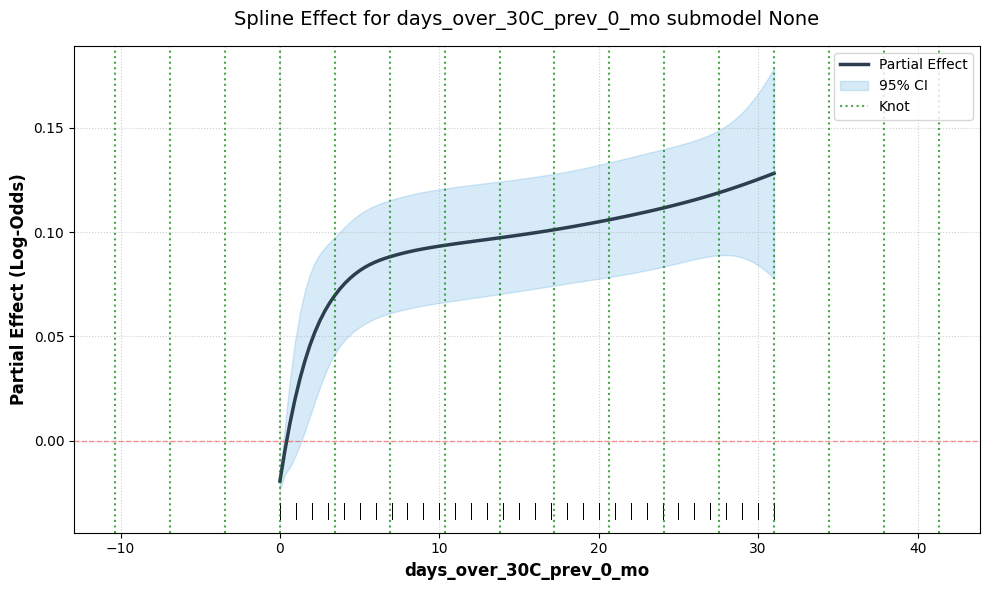

In [ ]:
plot_scam_spline(
    effect_df,
    raw_df,
    var.name,
    knots=transformed_knots,
    title=f"Spline Effect for {var.name} submodel {submodel}",
    # filepath=cm_data.models
    # / model_version
    # / f"spline_effect_{var.name}{submodel}.png",
)

In [ ]:
var = model_spec.predictors[5]

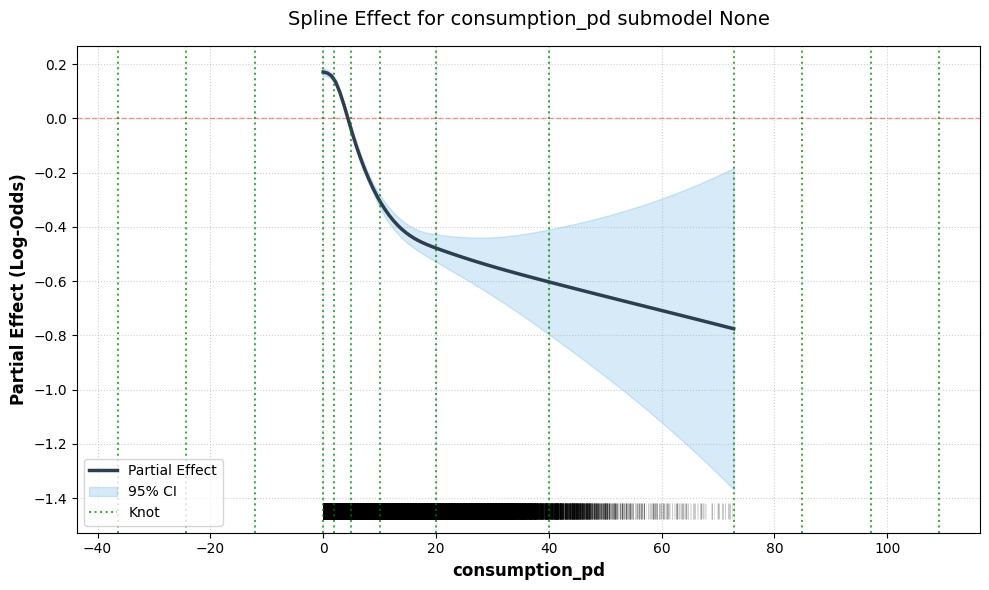

In [ ]:
if var.spline:
    effect_df = get_scam_spline_effect(model, var.name, df, value_source=raw_df)
    knots = extract_knots_from_model(model, var.name)
    if var.transform and var.transform.type == "scaling":
        transformed_knots = var_info[var.name]["transformer"].inverse_transform(knots)
    else:
        transformed_knots = knots
    effect_df.to_parquet(
        cm_data.models / model_version / f"spline_effect_{var.name}{submodel}.parquet"
    )
    plot_scam_spline(
        effect_df,
        raw_df,
        var.name,
        knots=transformed_knots,
        title=f"Spline Effect for {var.name} submodel {submodel}",
        # filepath=cm_data.models
        # / model_version
        # / f"spline_effect_{var.name}{submodel}.png",
    )

In [ ]:
effect_df

,value,effect,se
0,0.000075,0.171308,0.007519
1,0.735236,0.167235,0.006502
2,1.470397,0.156956,0.005668
3,2.205557,0.134431,0.004508
4,2.940718,0.097368,0.003175
...,...,...,...
95,69.840343,-0.759554,0.279396
96,70.575503,-0.763455,0.285018
97,71.310664,-0.767365,0.290711
98,72.045825,-0.771284,0.296478


In [ ]:
raw_df.head()

,birth_year,neonatal_mortality,consumption_pd,days_over_30C_prev_0_mo,intercept,sex_id,total_precipitation_prev_0_mo,ihme_loc_id,fits,no_re_fits
0,2009,0,8.917788,0.0,1.0,2,9.163333,GUY,0.016986,0.018578
1,2010,1,0.993143,4.0,1.0,2,2.583871,BFA,0.034598,0.030996
2,2013,1,2.134786,0.0,1.0,1,7.100000,BDI,0.032437,0.032525
3,2009,0,9.408828,0.0,1.0,1,7.860000,GUY,0.021414,0.023412
4,2013,1,1.416617,0.0,1.0,1,8.536667,COD,0.037105,0.033006


In [ ]:
raw_df["days_over_30C_prev_0_mo"].unique()

array([ 0.,  4., 24.,  1., 17., 10.,  3., 18., 29., 12., 13., 30., 20.,
        2., 21.,  6., 31., 25., 19., 11.,  9.,  5., 16.,  7.,  8., 28.,
       15., 27., 23., 26., 14., 22.])

In [ ]:
sorted(raw_df["days_over_30C_prev_0_mo"].unique())

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(11.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(14.0),
 np.float64(15.0),
 np.float64(16.0),
 np.float64(17.0),
 np.float64(18.0),
 np.float64(19.0),
 np.float64(20.0),
 np.float64(21.0),
 np.float64(22.0),
 np.float64(23.0),
 np.float64(24.0),
 np.float64(25.0),
 np.float64(26.0),
 np.float64(27.0),
 np.float64(28.0),
 np.float64(29.0),
 np.float64(30.0),
 np.float64(31.0)]

In [ ]:
sorted(raw_df["days_over_30C_prev_0_mo"].value_counts())

[5652,
 5680,
 5694,
 5765,
 5840,
 5900,
 6107,
 6145,
 6420,
 6433,
 6469,
 6569,
 6594,
 6741,
 7009,
 7467,
 7592,
 7864,
 8029,
 8818,
 9121,
 9514,
 9868,
 10749,
 11754,
 13408,
 17299,
 18794,
 20491,
 23825,
 35006,
 1424907]

In [ ]:
raw_df["days_over_30C_prev_0_mo"].value_counts()

days_over_30C_prev_0_mo
0.0     1424907
1.0       35006
2.0       23825
30.0      20491
31.0      18794
3.0       17299
4.0       13408
5.0       11754
6.0       10749
29.0       9868
7.0        9514
28.0       9121
8.0        8818
9.0        8029
27.0       7864
10.0       7592
11.0       7467
12.0       7009
26.0       6741
13.0       6594
16.0       6569
14.0       6469
15.0       6433
25.0       6420
17.0       6145
18.0       6107
23.0       5900
20.0       5840
24.0       5765
21.0       5694
19.0       5680
22.0       5652
Name: count, dtype: int64

In [ ]:
var = model_spec.predictors[3]

In [ ]:
effect_df = get_scam_spline_effect(model, var.name, df, value_source=raw_df)
knots = extract_knots_from_model(model, var.name)
if var.transform and var.transform.type == "scaling":
    transformed_knots = var_info[var.name]["transformer"].inverse_transform(knots)
else:
    transformed_knots = knots

In [ ]:
knots

-10.333333,-6.888889,-3.444444,...,34.444444,37.888889,41.333333


In [ ]:
var.name

'days_over_30C_prev_0_mo'

In [ ]:
model

<rpy2.robjects.vectors.ListVector object at 0x7fa274f3a7d0> [19]
R classes: ('scam', 'glm', 'lm')
[FloatSexp..., FloatSexp..., StrSexpVe..., FloatSexp..., ..., FloatSexp..., FloatSexp..., ListSexpV..., StrSexpVe...]
  gcv.ubre: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa26eca6450> [14]
R classes: ('numeric',)
[-0.709168]
  dgcv.ubre: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa26eca6e90> [14]
R classes: ('numeric',)
[-0.000000, 0.000001, 0.000001]
  optimizer: <class 'rpy2.robjects.vectors.StrVector'>
  <rpy2.robjects.vectors.StrVector object at 0x7fa26eca69d0> [16]
R classes: ('character',)
['bfgs', 'newton']
  termcode: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa26eca6150> [14]
R classes: ('numeric',)
[1.000000]
...
  formula: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa26eca5790> [14]
R classes: ('proc_time',)
[1954.974000, 480.713000, 2435.867000, 0.000000, 0.000000]
  family: <class 'rpy2.robjects.vectors.FloatVector'>
  <rpy2.robjects.vectors.FloatVector object at 0x7fa26eca5510> [14]
R classes: ('numeric',)
[0.000000]
<rpy2.robjects.vectors.ListVector object at 0x7fa274f3a7d0> [19]
R classes: ('scam', 'glm', 'lm')
[FloatSexp..., FloatSexp..., StrSexpVe..., FloatSexp..., ..., FloatSexp..., FloatSexp..., ListSexpV..., StrSexpVe...]
  model: <class 'rpy2.robjects.vectors.StrVector'>
  <rpy2.robjects.vectors.StrVector object at 0x7fa26eca4810> [16]
R classes: ('character',)
['UBRE']

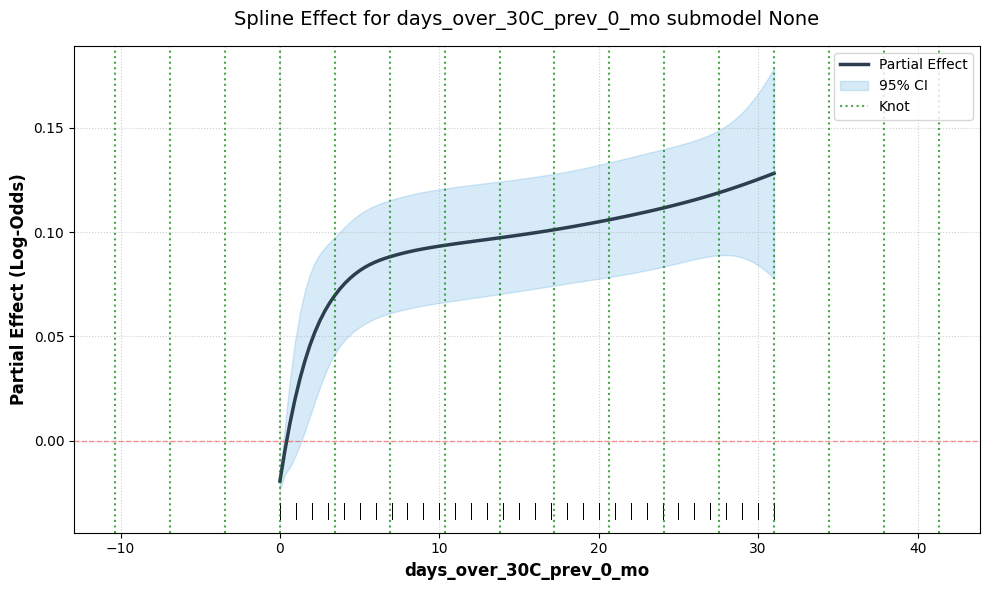

In [ ]:
plot_scam_spline(
    effect_df,
    raw_df,
    var.name,
    knots=transformed_knots,
    title=f"Spline Effect for {var.name} submodel {submodel}",
    # filepath=cm_data.models
    # / model_version
    # / f"spline_effect_{var.name}{submodel}.png",
)

In [ ]:
effect_df
original_data=raw_df.copy()
var_name=var.name
knots=transformed_knots
title=f"Spline Effect for {var.name} submodel {subm

SyntaxError: incomplete input (<ipython-input-44-262dc73f5b36>, line 5)

In [ ]:
effect_df
original_data = raw_df.copy()
var_name = var.name
knots = transformed_knots
title = f"Spline Effect for {var.name} submodel {submodel}"

In [ ]:
obs = original_data[var_name].dropna()

In [ ]:
obs

0           0.0
1           4.0
2           0.0
3           0.0
4           0.0
           ... 
1737519     2.0
1737520     0.0
1737521    28.0
1737522     6.0
1737523     0.0
Name: days_over_30C_prev_0_mo, Length: 1737524, dtype: float64

In [ ]:
obs.columns

AttributeError: 'Series' object has no attribute 'columns'

In [ ]:
obs.name

'days_over_30C_prev_0_mo'

In [ ]:
obs["days_over_30C_prev_0_mo"]

KeyError: 'days_over_30C_prev_0_mo'

In [ ]:
obs.value_counts()

days_over_30C_prev_0_mo
0.0     1424907
1.0       35006
2.0       23825
30.0      20491
31.0      18794
3.0       17299
4.0       13408
5.0       11754
6.0       10749
29.0       9868
7.0        9514
28.0       9121
8.0        8818
9.0        8029
27.0       7864
10.0       7592
11.0       7467
12.0       7009
26.0       6741
13.0       6594
16.0       6569
14.0       6469
15.0       6433
25.0       6420
17.0       6145
18.0       6107
23.0       5900
20.0       5840
24.0       5765
21.0       5694
19.0       5680
22.0       5652
Name: count, dtype: int64

In [ ]:
do30_vc = pd.DataFrame(obs.value_counts())

In [ ]:
do30_vc

,count
days_over_30C_prev_0_mo,
0.0,1424907
1.0,35006
2.0,23825
30.0,20491
31.0,18794
3.0,17299
4.0,13408
5.0,11754
6.0,10749


In [ ]:
print(do30_vc)

                           count
days_over_30C_prev_0_mo         
0.0                      1424907
1.0                        35006
2.0                        23825
30.0                       20491
31.0                       18794
3.0                        17299
4.0                        13408
5.0                        11754
6.0                        10749
29.0                        9868
7.0                         9514
28.0                        9121
8.0                         8818
9.0                         8029
27.0                        7864
10.0                        7592
11.0                        7467
12.0                        7009
26.0                        6741
13.0                        6594
16.0                        6569
14.0                        6469
15.0                        6433
25.0                        6420
17.0                        6145
18.0                        6107
23.0                        5900
20.0                        5840
24.0      

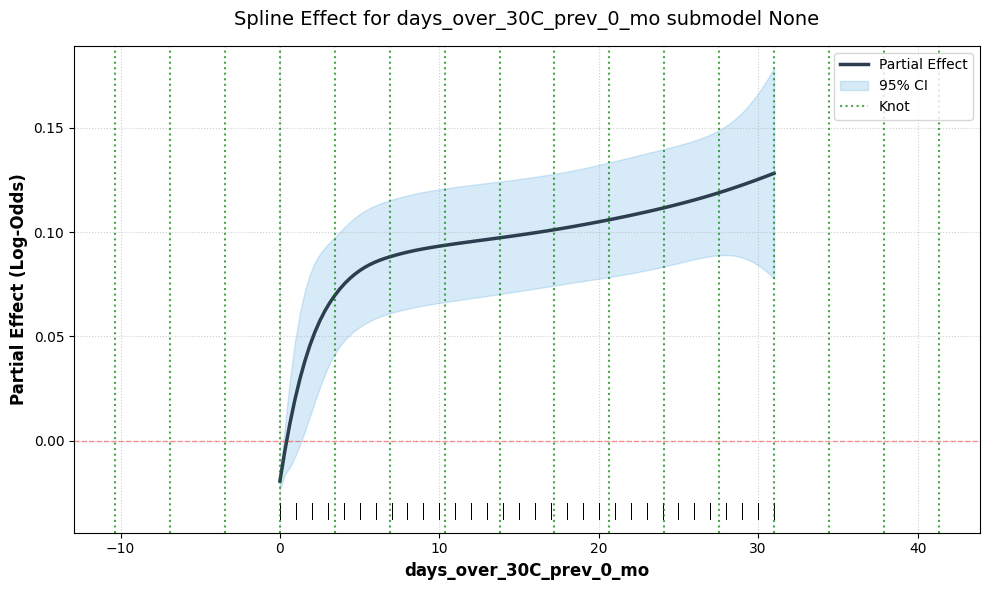

In [ ]:
plot_scam_spline(
    effect_df,
    raw_df,
    var.name,
    knots=transformed_knots,
    title=f"Spline Effect for {var.name} submodel {submodel}",
    # filepath=cm_data.models
    # / model_version
    # / f"spline_effect_{var.name}{submodel}.png",
)

In [ ]:
def plot_scam_spline(
    effect_df, original_data, var_name, knots=None, title=None, filepath=None
):
    """
    Plots a SCAM spline effect with 95% CI and a rug plot.

    Parameters:
    - effect_df: DataFrame with ['value', 'effect', 'se']
    - original_data: The full DataFrame (used for the rug plot)
    - var_name: Name of the variable being plotted (e.g., 'temperature')
    - knots: List of knot values (optional)
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # 1. Plot the Partial Effect (Spline)
    ax.plot(
        effect_df["value"],
        effect_df["effect"],
        color="#2c3e50",
        lw=2.5,
        label="Partial Effect",
    )

    # 2. Add 95% Confidence Interval (1.96 * SE)
    lower_ci = effect_df["effect"] - (1.96 * effect_df["se"])
    upper_ci = effect_df["effect"] + (1.96 * effect_df["se"])

    ax.fill_between(
        effect_df["value"],
        lower_ci,
        upper_ci,
        color="#3498db",
        alpha=0.2,
        label="95% CI",
    )

    # 3. Add the Rug Plot (The 'Rug' represents actual data distribution)
    # We place it at the very bottom of the current Y-axis
    obs = original_data[var_name].dropna()
    y_min = ax.get_ylim()[0]
    # ax.plot(
    #     obs,
    #     np.full_like(obs, y_min),
    #     "|",
    #     color="black",
    #     alpha=0.2,
    #     markersize=12,
    #     markeredgewidth=0.4,
    # )
    ax2 = ax.twinx()
    counts = original_data[var_name].dropna().value_counts().sort_index()
    ax2.bar(
        counts.index,
        counts.values,
        width=0.8,
        color="gray",
        alpha=0.3,
        label="Data density",
    )
    ax2.set_ylabel("Observation Count", fontsize=10, alpha=0.6)
    ax2.tick_params(axis="y", labelsize=8, colors="gray")
    # Keep spline plot on top
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    # 4. Reference line at 0 (No effect)
    ax.axhline(0, color="red", linestyle="--", alpha=0.4, lw=1)

    # 5. Add vertical lines for knots if provided
    if knots is not None:
        for knot in knots:
            ax.axvline(
                knot,
                color="green",
                linestyle=":",
                alpha=0.7,
                lw=1.5,
                label="Knot" if knot == knots[0] else None,
            )

    # 5. Aesthetics
    ax.set_xlabel(f"{var_name}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Partial Effect (Log-Odds)", fontsize=12, fontweight="bold")

    full_title = title if title else f"SCAM Spline Effect: {var_name}"
    ax.set_title(full_title, fontsize=14, pad=15)

    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(frameon=True, loc="best")

    plt.tight_layout()
    if filepath:
        plt.savefig(filepath, dpi=300)
    else:
        plt.show()

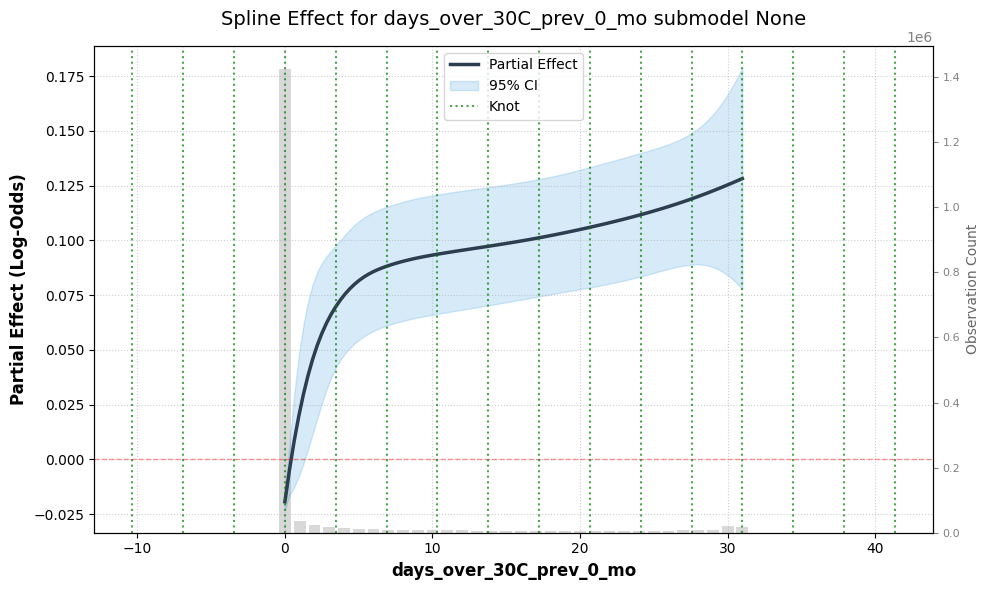

In [ ]:
plot_scam_spline(
    effect_df,
    raw_df,
    var.name,
    knots=transformed_knots,
    title=f"Spline Effect for {var.name} submodel {submodel}",
    # filepath=cm_data.models
    # / model_version
    # / f"spline_effect_{var.name}{submodel}.png",
)

In [ ]:
df.query(“days_over_30C != 0”).quantile([0.25, 0.5, 0.75])

SyntaxError: invalid character '“' (U+201C) (<ipython-input-58-0f2cc489f0fd>, line 1)